# Simulation of a Schwarzschild Black Hole
### The Deflection of Light Around a Black Hole

**Sara Carlos Cardoso** · Universidade de Aveiro, Departamento de Física · 2024/2025

---

This notebook implements a numerical ray-tracing framework to simulate photon trajectories in Schwarzschild spacetime. The goal is to understand how the curvature of spacetime around a non-rotating black hole governs the fate of light rays, and to reproduce the key observational features — shadow, lensing ring, and photon ring — that have gained renewed attention following the Event Horizon Telescope (EHT) results of 2019.

The work is based on the theoretical framework developed in:
- **Gralla, Holz & Wald (2019)**, *Black Hole Shadows, Photon Rings, and Lensing Rings*, PRD 100, 024018.

---
## 1 · Theoretical Background

### 1.1 The Schwarzschild Metric

The Schwarzschild solution is the unique spherically symmetric, static, vacuum solution to the Einstein Field Equations (setting $G = c = 1$):

$$ds^2 = -\left(1 - \frac{2M}{r}\right)dt^2 + \left(1 - \frac{2M}{r}\right)^{-1}dr^2 + r^2\,d\theta^2 + r^2\sin^2\theta\,d\varphi^2$$

Two radii are of special importance:

| Quantity | Value | Physical meaning |
|---|---|---|
| Event horizon | $r_s = 2M$ | One-way causal boundary; no signal escapes |
| Photon sphere | $r_p = 3M$ | Radius of unstable circular photon orbits |
| Critical impact parameter | $b_c = 3\sqrt{3}\,M \approx 5.196\,M$ | Separates captured from escaping rays |

### 1.2 Null Geodesics and the Impact Parameter

For a massless photon ($ds^2 = 0$) moving in the equatorial plane ($\theta = \pi/2$), the conserved energy $E$ and angular momentum $L$ yield the impact parameter:

$$b = \frac{L}{E}$$

which geometrically represents the perpendicular distance from the trajectory to the black hole axis at large distances. Using the Schwarzschild symmetries, the geodesic equation reduces to a single first-order ODE in $\varphi(r)$:

$$\frac{d\varphi}{dr} = \pm \frac{1}{r^2\,\sqrt{V(r,\,b)}}, \qquad V(r,b) = \frac{1}{b^2} - \frac{1}{r^2}\left(1 - \frac{r_s}{r}\right)$$

The sign $+$ applies to inbound motion (decreasing $r$) and $-$ to outbound (increasing $r$). Turning points — where the photon reverses its radial direction — occur at the zeros of $V(r,b)$.

### 1.3 Photon Classification

The critical impact parameter $b_c = 3\sqrt{3}M$ is derived from the conditions for an unstable circular orbit at $r = 3M$:

$$\frac{dV_{\rm eff}}{dr}\bigg|_{r=3M} = 0 \quad\Longrightarrow\quad b_c = 3\sqrt{3}\,M$$

Based on $b$ and the number of equatorial plane crossings $n = \varphi/2\pi$, photon trajectories fall into three classes (Gralla, Holz & Wald 2019):

| Class | Condition | Colour |
|---|---|---|
| **Direct** | $n < 3/4$, $b/M \notin (5.02,\,6.17)$ | Blue / Grey |
| **Lensed** | $3/4 < n < 5/4$, $b/M \in (5.02,5.19)\cup(5.23,6.17)$ | Orange |
| **Photon ring** | $n > 5/4$, $b/M \in (5.19,\,5.23)$ | Red |

Within the photon ring band, the fate of the ray depends solely on whether $b$ is above or below $b_c$:
- $b < b_c$: no outer turning point $\Rightarrow$ ray is **absorbed**
- $b > b_c$: outer turning point exists just outside $r = 3M$ $\Rightarrow$ ray **escapes**

---
## 2 · Numerical Implementation

### Ray-Tracing Method

The simulation integrates the orbit equation $d\varphi/dr$ numerically using `scipy.integrate.solve_ivp` with the `DOP853` method (an explicit 8th-order Runge–Kutta scheme with adaptive step-size control). Each trajectory is split into:

1. **Inbound segment**: from $r_{\rm start} = 50\,M$ inward to the turning point $r_{\rm turn}$ (or to the event horizon for absorbed rays).
2. **Outbound segment**: from $r_{\rm turn}$ back out to $r_{\rm final} = 50\,M$.

The turning point is located by scanning the effective potential $V(r,b)$ for sign changes and refining with Brent's method (`scipy.optimize.brentq`). Tolerances are tightened near the photon sphere ($|b - b_c| < 0.006\,M$) where the potential is nearly flat and numerical errors accumulate most rapidly.


Direct rays (180):


100%|██████████| 180/180 [07:38<00:00,  2.55s/it]


  plotted: 180

Lensed rays (112):


100%|██████████| 112/112 [06:04<00:00,  3.25s/it]


  plotted: 112

Photon ring rays (41):


100%|██████████| 41/41 [03:19<00:00,  4.87s/it]


  plotted: 41


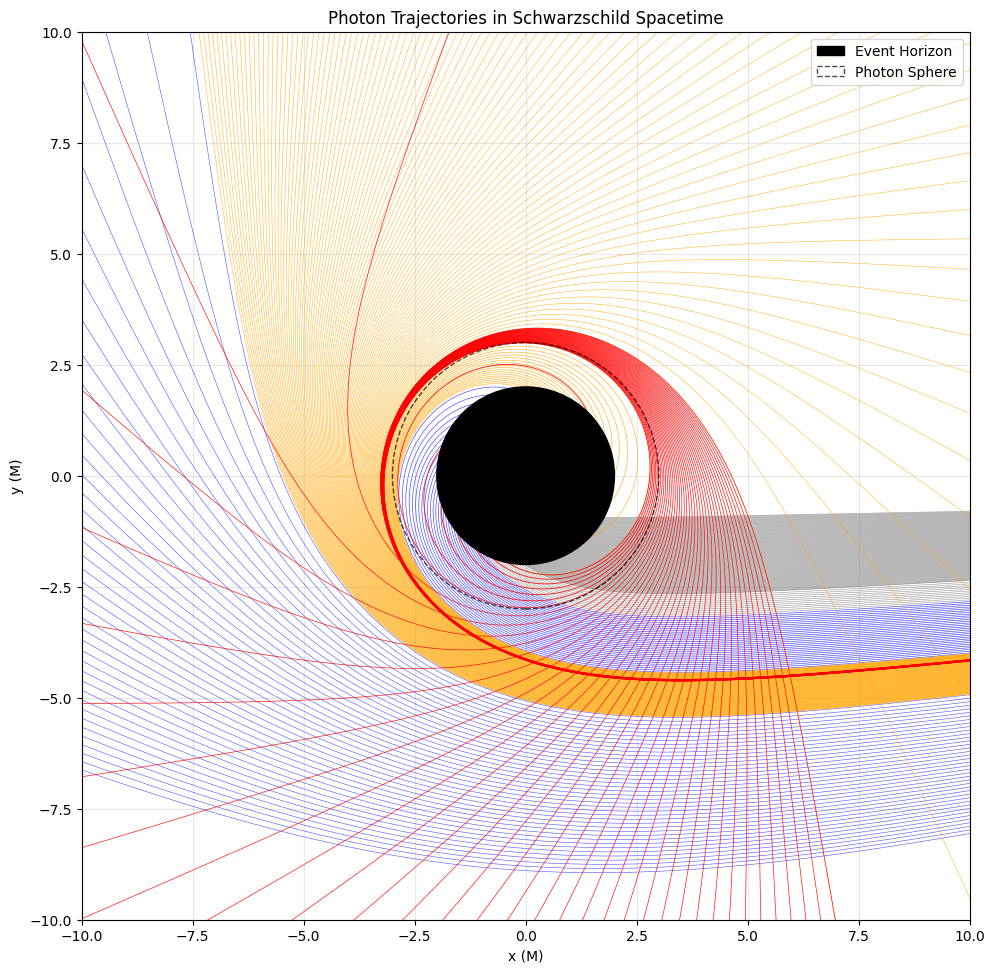

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
from tqdm import tqdm


class SchwarzschildPhotons:
    def __init__(self, M=1):
        self.M = M
        self.rs = 2 * M
        self.r_photon = 3 * M
        self.b_crit = 3 * np.sqrt(3) * M   # ≈ 5.1962 M

    #effective potential
    def V(self, r, b):
        """V(r,b) = 1/b² − (1−rs/r)/r²  — zeros give turning points."""
        return 1.0 / b**2 - (1.0 - self.rs / r) / r**2

    #turning-point finder
    def outer_turning_point(self, b):
        """
        Return the OUTER turning point for b > b_crit, else None.
        b < b_crit  →  V ≥ 0 everywhere outside horizon →  no turning point  →  ray absorbed.
        b > b_crit  →  V dips negative near r = 3M  →  two roots.
        Ray from infinity bounces off the OUTER root and escapes.
        """
        if b <= self.b_crit:
            return None
        r_hi = max(b * 3, 50.0)
        r_arr = np.linspace(self.rs + 0.001, r_hi, 600_000)
        V_arr = self.V(r_arr, b)
        sc = np.where(np.diff(np.sign(V_arr)))[0]
        if len(sc) == 0:
            return None
        i = sc[-1]   # OUTER root = last sign change
        try:
            return brentq(self.V, r_arr[i], r_arr[i + 1],
                        args=(b,), xtol=1e-12, rtol=1e-12)
        except Exception:
            return None

    #ODE integration helper
    def _integrate(self, r_span, phi0, b, inbound,
                rtol=1e-11, atol=1e-13, max_step=0.005, events=None):
        """Integrate dφ/dr = ±1 / (r² √V) over r_span."""
        sign = +1.0 if inbound else -1.0
        rs = self.rs

        def ode(r, y):
            if r <= rs + 1e-10:
                return [0.0]
            v = self.V(r, b)
            if v <= 1e-20:
                return [0.0]
            return [sign / (r**2 * np.sqrt(v))]

        sol = solve_ivp(ode, r_span, [phi0],
                        method='DOP853',
                        rtol=rtol, atol=atol,
                        max_step=max_step,
                        events=events,
                        dense_output=False)
        if len(sol.t) < 2:
            return None, None
        return sol.t, sol.y[0]

    # ── trajectory builders ───────────────────────────────────────────────────

    def _traj_absorbed(self, b, r_start):
        """Ray spirals into the BH — integrate inbound to the event horizon."""
        eh = self.rs + 1e-8

        def hit(r, y): return r - eh
        hit.terminal = True
        hit.direction = -1

        r, phi = self._integrate([r_start, eh], 0.0, b, inbound=True,
                                rtol=1e-12, atol=1e-14, events=hit)
        return r, phi, True

    def _traj_bounce(self, b, r_start, r_turn, r_final,
                    rtol=1e-11, atol=1e-13, ms=0.005):
        """
        Ray bounces once off r_turn.
        Two segments: r_start → r_turn (inbound) → r_final (outbound).
        """
        buf = max(1e-9, abs(r_turn - self.r_photon) * 1e-7)
        r_stop = r_turn + buf

        r_in, phi_in = self._integrate([r_start, r_stop], 0.0, b,
                                    inbound=True, rtol=rtol, atol=atol, max_step=ms)
        if r_in is None:
            return None, None, False

        r_out, phi_out = self._integrate([r_stop, r_final], phi_in[-1], b,
                                        inbound=False, rtol=rtol, atol=atol, max_step=ms)
        if r_out is None:
            return r_in, phi_in, False

        return (np.concatenate([r_in, r_out[1:]]),
                np.concatenate([phi_in, phi_out[1:]]),
                False)

    #public trajectory interface 
    def generate_full_trajectory(self, b, r_start=50, r_final=50):
        """
        Returns (r_array, phi_array, absorbed).

        Orbit classification (Gralla, Holz & Wald 2019, Fig. 2):
        direct b ∉ (5.02, 6.17)
        lensed b ∈ (5.02, 5.19) ∪ (5.23, 6.17)  [3/4 < n < 5/4]
        photon ring b ∈ (5.19, 5.23) [n > 5/4]

        Whether a ray is absorbed or escapes is determined solely by b vs b_crit:
        b < b_crit ≈ 5.196 →  absorbed (no outer turning point)
        b > b_crit →  escaping (bounces off outer turning point)
        """
        eh = self.rs + 1e-8

        #find turning point (works for all orbit types)
        r_hi = max(b * 3, 50.0)
        r_arr = np.linspace(self.rs + 0.001, r_hi, 600_000)
        V_arr = self.V(r_arr, b)
        sc = np.where(np.diff(np.sign(V_arr)))[0]

        if len(sc) == 0:
            #V ≥ 0 everywhere → b < b_crit → absorbed
            return self._traj_absorbed(b, r_start)

        #Outer turning point exists
        i = sc[-1]
        try:
            r_turn = brentq(self.V, r_arr[i], r_arr[i + 1],
                            args=(b,), xtol=1e-12, rtol=1e-12)
        except Exception:
            return self._traj_absorbed(b, r_start)

        if r_turn <= self.rs + 1e-6:
            return self._traj_absorbed(b, r_start)

        #set integration tolerances based on proximity to b_crit
        dist = abs(b - self.b_crit)
        if dist < 0.002:
            rtol, atol, ms = 1e-13, 1e-15, 0.001
        elif dist < 0.006:
            rtol, atol, ms = 1e-12, 1e-14, 0.002
        else:
            rtol, atol, ms = 1e-11, 1e-13, 0.005

        return self._traj_bounce(b, r_start, r_turn, r_final,
                                rtol=rtol, atol=atol, ms=ms)

    #plotting helpers
    def classify_orbit(self, b):
        if 5.02 <= b <= 5.19 or 5.23 <= b <= 6.17:
            return 'lensed'
        elif 5.19 < b < 5.23:
            return 'photon_ring'
        else:
            return 'direct'

    def plot_single_trajectory(self, b, color, lw, alpha, ax):
        try:
            r_vals, phi_vals, absorbed = self.generate_full_trajectory(b)
        except Exception:
            return 'error'
        if r_vals is None or len(r_vals) < 2:
            return 'no_trajectory'

        mask = r_vals > self.rs + 1e-10
        r_vals, phi_vals = r_vals[mask], phi_vals[mask]
        if len(r_vals) < 2:
            return 'too_short'

        ax.plot(r_vals * np.cos(phi_vals), r_vals * np.sin(phi_vals),
                color=color,
                lw=lw * (1.2 if absorbed else 1.0),
                alpha=alpha)
        return 'absorbed_plotted' if absorbed else 'complete_plotted'


    def plot_trajectories(self):
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.set_aspect('equal')
        ax.set_xlim(-10, 10)
        ax.set_ylim(-10, 10)
        ax.grid(True, alpha=0.3)
        ax.set_title("Photon Trajectories in Schwarzschild Spacetime")
        ax.set_xlabel('x (M)')
        ax.set_ylabel('y (M)')

        bh = plt.Circle((0, 0), self.rs, color='k', zorder=10,
                        label='Event Horizon')
        ps = plt.Circle((0, 0), self.r_photon, color='none', ec='k',
                        ls='--', alpha=0.7, zorder=5, label='Photon Sphere')
        ax.add_patch(bh)
        ax.add_patch(ps)

        #impact parameter grids (matching paper Fig. 2 spacing)
        b_direct = np.concatenate([
            np.arange(6.18, 10.1, 0.1), #spacing 1/10
            np.arange(2.95, 5.02, 0.05),
            np.arange(1.0,  2.95, 0.02),
        ])
        b_lensed = np.concatenate([
            np.arange(5.02, 5.19, 0.01), #spacing 1/100
            np.arange(5.23, 6.17, 0.01),
        ])
        #Photon ring: b ∈ (5.19, 5.23), spacing 1/1000 (paper)
        #b < b_crit ≈ 5.196 → absorbed;  b > b_crit → escaping
        b_photon_ring = np.arange(5.190, 5.230, 0.001)

        cfg = {
            'direct': ('blue', 0.4, 0.7),
            'small_direct': ('gray', 0.4, 0.7),
            'lensed': ('orange', 0.4, 0.8),
            'photon_ring': ('red', 0.5, 0.9),
        }

        def run_batch(b_arr, label, color_key):
            print(f"\n{label} ({len(b_arr)}):")
            ok = 0
            for b in tqdm(b_arr):
                ck = ('small_direct'
                    if color_key == 'direct' and b < 3.5
                    else color_key)
                c, lw, al = cfg[ck]
                if self.plot_single_trajectory(b, c, lw, al, ax) in (
                        'complete_plotted', 'absorbed_plotted'):
                    ok += 1
            print(f"plotted: {ok}")

        run_batch(b_direct, "Direct rays", 'direct')
        run_batch(b_lensed, "Lensed rays", 'lensed')
        run_batch(b_photon_ring, "Photon ring rays", 'photon_ring')

        ax.legend([bh, ps], ['Event Horizon', 'Photon Sphere'], loc='upper right')
        plt.tight_layout()
        plt.show()


# ── entry point ───────────────────────────────────────────────────────────────

sp = SchwarzschildPhotons(M=1)
sp.plot_trajectories()

---
## 3 · Transfer Functions

### Disk Crossing Structure

For a face-on, optically thin accretion disk lying in the equatorial plane, each photon traced back from the observer may cross the disk plane multiple times. The **transfer functions** $r_m(b)$ map each observed impact parameter $b$ to the radial coordinate $r$ of the $m$-th intersection with the disk:

- **First crossing** ($m=1$, at $\varphi = -\pi/2$): the **direct image** — essentially a redshifted copy of the emission profile, with slope $dr/db \approx 1$.
- **Second crossing** ($m=2$, at $\varphi = -3\pi/2$): the **lensed image** of the back side of the disk, appearing in the lensing ring $b/M \in (5.02,\,6.17)$. This image is demagnified by a factor of $\sim 20$.
- **Third crossing** ($m=3$, at $\varphi = -5\pi/2$): a further demagnified image of the front side of the disk, confined to the narrow photon ring $b/M \in (5.19,\,5.23)$, contributing negligibly to the total flux.

The calculation uses the substitution $u = 1/r$ to rewrite the geodesic as a second-order ODE:

$$\frac{d^2u}{d\varphi^2} + u = 3M u^2$$

which is then integrated from $\varphi = 0$ to $\varphi = -2\pi$ for each value of $b$. The radial positions at the target angles $\varphi = -\pi/2,\,-3\pi/2,\,-5\pi/2$ give $r_1$, $r_2$, and $r_3$ respectively.

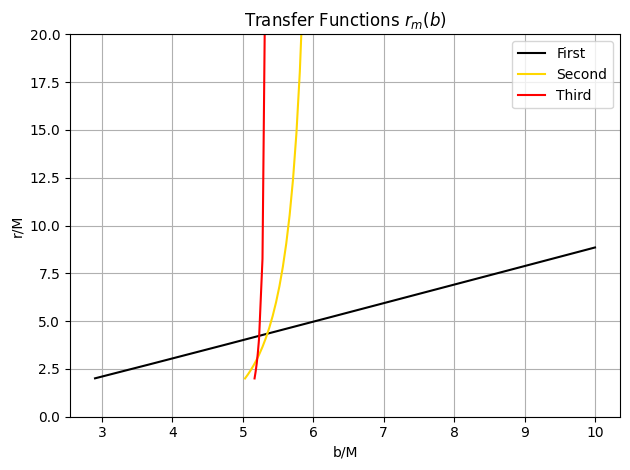

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

M = 1

#Dense sampling near the photon ring (b/M ∈ (5.19, 5.23)) where transfer
#functions vary rapidly; coarser spacing elsewhere is sufficient.
b_vals = np.concatenate([
    np.linspace(2.9, 5.0, 100),    # direct trajectories
    np.linspace(5.0, 5.23, 300),   # lensed + photon ring — fine resolution
    np.linspace(5.23, 10.0, 100),  # lensed (far side) + direct
])

# Second-order ODE for null geodesics in Schwarzschild spacetime,
# written in terms of u = 1/r (Binet substitution):
#   d²u/dφ² + u = 3M u²
# The RHS is the GR correction; without it (flat space) the solution is u = sin(φ)/b.
def geodesic(phi, y):
    u, du_dphi = y
    d2u_dphi2 = 3 * M * u**2 - u
    return [du_dphi, d2u_dphi2]

# Azimuthal angles at which the photon crosses the equatorial (disk) plane:
#   φ = -π/2   → 1st crossing (direct image,  m=1)
#   φ = -3π/2  → 2nd crossing (lensed image,  m=2)
#   φ = -5π/2  → 3rd crossing (photon ring,   m=3)
target_phis = [-np.pi/2, -3*np.pi/2, -5*np.pi/2]

r1_list, r2_list, r3_list = [], [], []

# Remove unphysical values: r must be finite and outside the event horizon (r > 2M).
# Crossings that failed to reach the target angle return NaN and are excluded from the plot.
def clean_r_list(r_list, max_r=100):
    return [r if np.isfinite(r) and 2 < r < max_r else np.nan for r in r_list]

for b in b_vals:
    # Start the photon far from the black hole (r₀ = 100 M ≫ b_crit)
    r0 = 100
    u0 = 1 / r0

    # Negative sign on du/dφ ensures the photon travels inward (toward the BH).
    # From the null geodesic: du/dφ|∞ = -1/b for a ray arriving from r → ∞.
    du_dphi0 = -1 / b

    y0 = [u0, du_dphi0]

    # Integrate from φ = 0 to φ = -2π (one full revolution in the retrograde direction)
    phi_span = (0, -2 * np.pi)
    phi_eval = np.linspace(*phi_span, 10000)

    sol = solve_ivp(geodesic, phi_span, y0, t_eval=phi_eval, rtol=1e-9, atol=1e-9)

    phi = sol.t
    u = sol.y[0]
    r = 1 / u           # convert back from u = 1/r to r

    # Find r at each target angle by locating the nearest evaluated point.
    # A proper event-based approach would be more accurate, but this is
    # sufficient given the 10 000-point evaluation grid.
    crossings = []
    for tgt_phi in target_phis:
        idx = np.argmin(np.abs(phi - tgt_phi))
        crossings.append(r[idx] if 0 <= idx < len(r) else np.nan)

    r1_list.append(crossings[0])
    r2_list.append(crossings[1])
    r3_list.append(crossings[2])

# Apply the physical filter only to the 2nd and 3rd transfer functions;
# the 1st (direct image) is well-behaved across the full b range.
r2_list = clean_r_list(r2_list)
r3_list = clean_r_list(r3_list)

plt.plot(b_vals, r1_list, label='First',  color='black')
plt.plot(b_vals, r2_list, label='Second', color='gold')
plt.plot(b_vals, r3_list, label='Third',  color='red')
plt.xlabel("b/M")
plt.ylabel("r/M")
plt.title("Transfer Functions $r_m(b)$")
plt.ylim(0, 20)
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

---
## 4 · Summary

The simulations confirm the theoretical predictions of Schwarzschild ray-tracing:

- **Direct rays** ($b/M \notin (5.02, 6.17)$) experience a single gravitational deflection and escape to infinity, or are absorbed if $b < b_c$.
- **Lensed rays** ($b/M \in (5.02,5.19) \cup (5.23,6.17)$) wrap partially around the black hole before escaping, producing a demagnified image of the far side of any surrounding disk — the **lensing ring**.
- **Photon ring rays** ($b/M \in (5.19,5.23)$) orbit very close to the photon sphere ($r = 3M$) before either escaping or falling in. They produce an extremely narrow, bright feature whose contribution to the total observed flux is only logarithmically enhanced — and hence observationally negligible at present EHT resolution.

The transfer functions demonstrate the multi-image structure: each observed impact parameter $b$ in the lensing/photon-ring band corresponds to multiple distinct regions of the disk, with each successive image exponentially more demagnified than the previous one.

---
*Supervisor: Dr. Mercè Guerrero Román · Universidade de Aveiro*